In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve

In [4]:
df = pd.read_csv(
    '../datasets/nutriscore_donnees_propres_final.csv',
    sep=";",
    engine="python"
)

In [12]:
df.dropna()

,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
3,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.80000,0.7,0.280,28.781250
4,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.10000,0.7,0.304,31.666667
5,112302656,Lié big purSoup mouliné de 10 Légumes,3,c,en:vegetable-soups,150.0,1.2,0.4,4.6,1.4,1.50000,0.9,0.280,24.750000
6,112302660,Soupe potiron et kiri,3,c,en:vegetable-soups,161.0,1.5,1.0,4.9,2.0,0.80000,0.9,0.296,34.312500
7,112302676,Velouté de légumes du soleil,3,c,en:canned-vegetable-soups,147.5,1.7,0.3,3.7,1.4,0.80000,0.9,0.268,29.301250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279805,9876000000064,Chocolat Vegan Amandes Caramel Salé Équitable Bio,36,e,en:plant-milk-chocolates,2267.0,35.0,20.0,55.0,41.0,2.80000,3.0,0.792,0.000000
279809,9898909057345,Pão de Fôrma 35% Integral - Visconti - 400g,3,c,en:wholemeal-sliced-breads,593.5,2.1,0.6,25.0,6.0,2.00000,4.4,0.188,0.000000
279839,990530101020365169,Gâche tranchée,11,d,fr:gaches,931.8,8.0,5.4,32.0,8.7,3.75475,5.4,0.268,0.000000
279846,990530101025174626,Mon haché burger 100% pur boeuf,6,c,en:ground-beef-steaks,775.5,12.0,5.4,0.5,0.5,0.00000,19.0,0.088,0.000000


In [13]:
df.head()

,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
0,101019680,Donut Milka,23,e,en:doughnuts,1928.5,28.0,13.8,46.5,18.0,NaN,6.000000,0.2596,NaN
1,102005708,Chorizo,14,d,en:chorizo,1357.90002822874,36.700000762939,12.699999809265,0.0,0.0,NaN,0.000000,0.0000,NaN
2,102005952,Chorizo,35,e,en:chorizo,1771.89995718005,35.299999237061,12.199999809265,5.1,4.1,NaN,22.299999,1.5600,NaN
3,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.8,0.700000,0.2800,28.781250
4,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.1,0.700000,0.3040,31.666667


In [5]:

X = df.drop(columns=['code', 'product_name', 'nutriscore_score', 'nutriscore_grade', 'main_category'])
y = df['nutriscore_grade']


X = X.replace({'not-applicable': np.nan, 'not applicable': np.nan, 'not applicable': np.nan})


X = X.apply(pd.to_numeric, errors='coerce')


X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print("Shape X :", X.shape)
print("Vérification NaN :", X.isnull().sum().sum(), "valeurs manquantes")
print("Types :", X.dtypes.unique())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

Shape X : (279878, 9)
Vérification NaN : 199340 valeurs manquantes
Types : [dtype('float64')]
              precision    recall  f1-score   support

           a       0.91      0.91      0.91      8268
           b       0.84      0.83      0.83      6681
           c       0.90      0.91      0.91     14147
           d       0.93      0.94      0.93     13425
           e       0.96      0.95      0.95     13455

    accuracy                           0.92     55976
   macro avg       0.91      0.91      0.91     55976
weighted avg       0.92      0.92      0.92     55976



C:\Users\enzol\Desktop\Python\mon_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[learning_curve] Training set sizes: [ 22390  44780  67170  89560 111951 134341 156731 179121 201511 223902]


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  9.7min finished


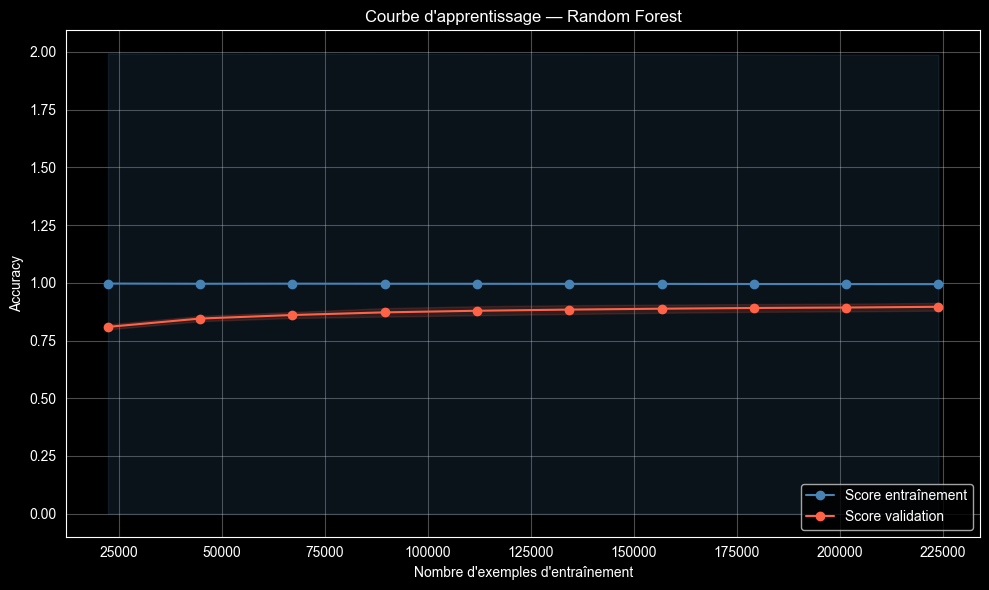

In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    verbose=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)


plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score entraînement')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='steelblue')

plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='Score validation')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='tomato')

plt.title('Courbe d\'apprentissage — Random Forest')
plt.xlabel('Nombre d\'exemples d\'entraînement')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()